# Detecting Stock Market Cycles
This Jupyter notebook is a supplementary resource for the article.
It contains all the code snippets and examples discussed in the article,
providing a hands-on approach to understanding the concepts and techniques presented.
For a comprehensive understanding, please refer to the article at
https://entreprenerdly.com/


<p align="left">
  <img src="https://bit.ly/3FB10Z4" height=400>
</p>

# Market-Cycle Composite: Technical Construction

The Market-Cycle Composite provides a single, standardized score to summarize broad economic and financial conditions over time.  
The composite aggregates multiple macroeconomic and market variables using objective, statistical transformations.

---

## Variable Selection and Rationale

The input variables are selected to capture the principal drivers of business and market cycles. Each series provides information about a distinct aspect of macro or market conditions:

- **LEI (Leading Economic Index):** Composite of forward-looking indicators. Used as a broad proxy for future economic activity.
- **Philly Manufacturing Diffusion Index:** Measures regional manufacturing strength. Early signal of industrial cycle turns.
- **Texas Services Diffusion Index:** Measures regional services activity. Used as a proxy for broader U.S. services sector momentum.
- **Capacity Utilization:** Indicates resource use in manufacturing. Declining utilization often precedes recessions.
- **Brave-Butters-Kelley (BBK) Leading Index:** Proprietary index for early-cycle turns in economic growth.
- **CFNAI 3-Month Moving Average:** Captures national activity, smoothing short-term volatility.

- **Core CPI, Core PCE, Hourly Wage, PPI, Commodities:** These five form an inflation composite. Core CPI and Core PCE measure underlying inflation. Hourly wage growth captures labor cost pressure. PPI represents input cost trends. Commodities index reflects global price changes.

- **10-Year Treasury Yield (12m delta, inverted):** Captures changes in long-term interest rates. Inversion aligns higher yields with restrictive conditions.
- **High Yield OAS (12m delta, inverted):** Measures corporate credit spreads as a risk sentiment indicator. Inverted so wider spreads lower the composite.
- **St. Louis Fed Financial Stress Index (inverted):** Measures systemic market stress. Inverted so increased stress lowers the composite.

---

## Methodological Steps

### 1. Data Processing

- Each series is resampled to a common frequency (typically month-end) to align timeframes.

    df = pd.DataFrame(raw).resample(FREQ).last().ffill()

### 2. Variable Transformation

- For most variables, use year-over-year percent change:

  $$
  \text{YoY Change}_t = \frac{S_t - S_{t-12}}{S_{t-12}} \times 100
  $$

- For interest rates and credit spreads, use 12-month difference and invert when appropriate:

  $$
  \Delta_{12}(S)_t = S_t - S_{t-12}
  $$

- For financial stress and risk proxies, invert so higher values represent deteriorating conditions.

### 3. Inflation Composite

- Compute the inflation block as the mean of Core CPI, Core PCE, Hourly Wage, PPI, and Commodities.

  $$
  \text{Inflation}_t = \frac{1}{5}\sum_{i=1}^{5} X_{i,t}
  $$

### 4. Z-Score Standardization

- Standardize each series to mean zero and standard deviation one:

  $$
  Z_{i,t} = \frac{X_{i,t} - \mu_i}{\sigma_i}
  $$

  Where $X_{i,t}$ is the input value, $\mu_i$ is mean, and $\sigma_i$ is standard deviation.

### 5. Composite Calculation

- The composite score is the mean of all standardized variables at each time:

  $$
  C_t = \frac{1}{N} \sum_{i=1}^{N} Z_{i,t}
  $$

  Where $N$ is the total number of input series (after inflation composite is constructed).

### 6. Smoothing

- Apply a simple moving average to reduce noise:

  $$
  C^{\text{sm}}_t = \frac{1}{w} \sum_{k=0}^{w-1} C_{t-k}
  $$

  Where $w$ is the smoothing window.

### 7. Slope Calculation

- Compute the composite change over a look-back window:

  $$
  \text{Slope}_t = C_t - C_{t-w}
  $$

### 8. Phase Assignment

- Define thresholds for composite ($\gamma$) and slope ($\delta$):

    - Early: $C_t < -\gamma$ and $\text{Slope}_t > +\delta$
    - Decline: $C_t < -\gamma$ and $\text{Slope}_t < -\delta$
    - Mid-Late: $C_t > +\gamma$
    - Uncertain: $|C_t| \leq \gamma$

### 9. Phase Smoothing

- Apply a centered rolling mode to assigned phases to suppress frequent regime shifts due to noise.

---

## Summary of Core Formulae

**Z-score Standardization:**  
$$
Z_{i,t} = \frac{X_{i,t} - \mu_i}{\sigma_i}
$$

**Composite Score:**  
$$
C_t = \frac{1}{N} \sum_{i=1}^{N} Z_{i,t}
$$

**Smoothed Composite:**  
$$
C^{\text{sm}}_t = \frac{1}{w} \sum_{k=0}^{w-1} C_{t-k}
$$

**Slope:**  
$$
\text{Slope}_t = C_t - C_{t-w}
$$

**Phase Assignment:**

\[
\begin{aligned}
&\text{Early:}      && C_t < -\gamma \;\&\; \text{Slope}_t > +\delta \\
&\text{Decline:}    && C_t < -\gamma \;\&\; \text{Slope}_t < -\delta \\
&\text{Mid-Late:}   && C_t > +\gamma \\
&\text{Uncertain:}  && |C_t| \leq \gamma \\
\end{aligned}
\]

---

This method aggregates diverse macro and market data into a normalized, dimensionless signal that is robust to outliers and applicable for regime classification in financial and economic analysis.


In [ ]:
import pandas as pd
import numpy as np
import pandas_datareader.data as web
import yfinance as yf
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from datetime import datetime
import matplotlib.dates as mdates
import math
plt.style.use('dark_background')

# PARAMETERS
START, END    = '2000-01-01', datetime.today().strftime('%Y-%m-%d')
FREQ          = 'ME'       # Pandas resample frequency for data (e.g. 'ME'=month‑end); controls aggregation period—higher freq ('D') adds noise, lower ('Q') smooths
SLOPE_WINDOW  = 3          # Look‑back periods for slope = comp.diff(SLOPE_WINDOW); larger values smooth and delay turn signals, smaller values speed detection but add volatility
SMOOTH_WINDOW = 2          # Window for composite moving average before plotting; larger windows yield a smoother but more lagged chart, smaller windows follow raw swings closely

In [ ]:
# SERIES MAP
fred_map = {
    # growth / activity
    'LEI'               : 'USSLIND',           # Leading Index for US (Philly Fed state leading), proxy for overall LEI
    'Philly Manuf Diff' : 'GACDFSA066MSFRBPHI',# Philly Fed manufacturing diffusion index, proxy for ISM Mfg PMI (ISM is no longer supported at Fred)
    'Texas Serv Diff'   : 'TSSOSBACTUAMFRBDAL',# Dallas Fed services diffusion index, proxy for ISM Services PMI (ISM is no longer supported at Fred)
    'Capacity Util'     : 'CUMFNS',            # Industrial capacity utilization rate
    'BBK Leading'       : 'BBKMLEIX',          # Brave‑Butters‑Kelley leading index, leading growth component
    'CFNAI 3MMA'        : 'CFNAIMA3',          # Chicago Fed National Financial Activity Index 3‑mo avg

    # inflation sub‑block
    'Core CPI'          : 'CPILFESL',          # Core CPI ex‑food & energy, inflation proxy
    'Core PCE'          : 'PCEPILFE',          # Core PCE inflation proxy
    'Hourly Wage'       : 'CES0500000003',     # Avg hourly earnings YoY (BLS)
    'PPI'               : 'PPIACO',            # Producer Price Index commodities YoY
    'Commodities'       : 'PALLFNFINDEXM',     # BCOM commodity price index YoY

    # rates & credit
    '10Y'               : 'DGS10',             # 10‑year Treasury yield (Δ12m)
    'HY OAS'            : 'BAMLH0A0HYM2',      # High‑yield OAS (Δ12m, inverted)

    # stress proxy
    'StLouis FSI'       : 'STLFSI4',           # St. Louis Fed Financial Stress Index (inverted)
}

# FETCH & RESAMPLE
raw = {k: web.DataReader(tkr, 'fred', START, END).squeeze()
       for k, tkr in fred_map.items()}
df  = pd.DataFrame(raw).resample(FREQ).last().ffill()

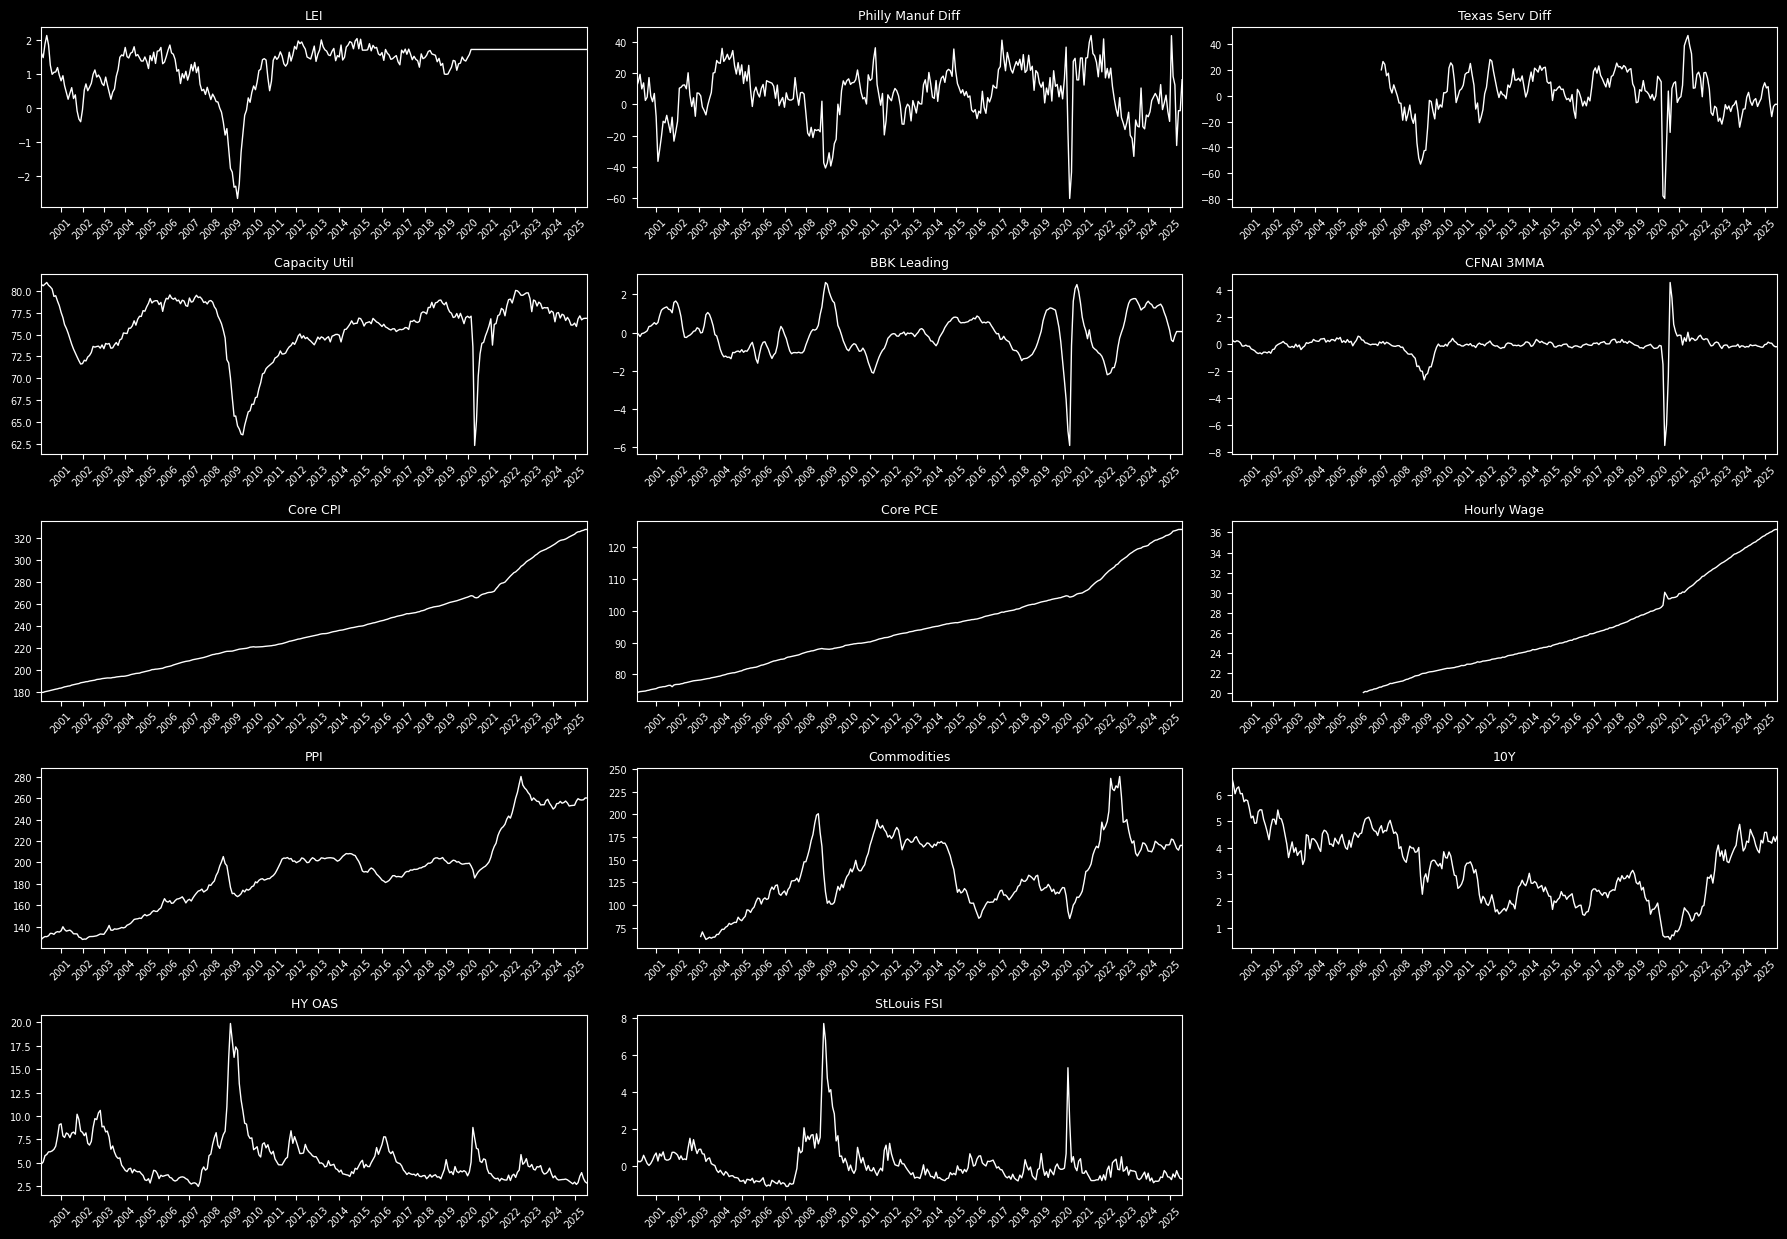

In [ ]:
# PLOT ALL SERIES

df_raw = df.copy()

# Determine grid size
n_series = len(df_raw.columns)
ncols    = 3
nrows    = math.ceil(n_series / ncols)

# sharex=False ⇒ each axis shows its own ticks
fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(ncols*6, nrows*2.5),
    sharex=False
)

# Flatten axes for easy iteration
axes_flat = axes.flatten()

xmin, xmax = df_raw.index.min(), df_raw.index.max()

for ax, col in zip(axes_flat, df_raw.columns):
    ax.plot(df_raw.index, df_raw[col], lw=1, color='white')
    ax.set_title(col, fontsize=9)
    # enforce same x‐limits on each
    ax.set_xlim(xmin, xmax)
    # format each x‐axis independently
    ax.xaxis.set_major_locator(mdates.YearLocator(1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.tick_params(axis='y', labelsize=7)

# Turn off any unused subplots
for ax in axes_flat[n_series:]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()


In [ ]:
# TRANSFORMS
yoy     = lambda s: s.pct_change(12) * 100
delta12 = lambda s: s.diff(12)
invert  = lambda s: -s

df['LEI']           = yoy(df['LEI'])
df['Capacity Util'] = yoy(df['Capacity Util'])
df['BBK Leading']   = yoy(df['BBK Leading'])
for c in ['Core CPI','Core PCE','Hourly Wage','PPI','Commodities']:
    df[c] = yoy(df[c])
df['10Y']        = invert(delta12(df['10Y']))
df['HY OAS']     = invert(delta12(df['HY OAS']))
df['StLouis FSI']= invert(df['StLouis FSI'])

In [ ]:
# INFLATION COMPOSITE
infl_cols = ['Core CPI','Core PCE','Hourly Wage','PPI','Commodities']
df['Inflation'] = df[infl_cols].mean(axis=1)

# FINAL INPUT LIST
inputs = [
    'LEI','Philly Manuf Diff','Texas Serv Diff',
    'Capacity Util','BBK Leading','CFNAI 3MMA',
    'Inflation','10Y','HY OAS','StLouis FSI'
]

In [ ]:
# Z-SCORES & COMPOSITE
z       = df[inputs].apply(lambda s: (s - s.mean())/s.std())
comp    = z.mean(axis=1)
comp_sm = comp.rolling(SMOOTH_WINDOW, min_periods=1).mean()
slope   = comp.diff(SLOPE_WINDOW)

In [ ]:
# PHASE CLASSIFICATION w/ DEAD‐ZONE
comp_thr, slope_thr = 0.15, 0.005
cond_early   = (comp < -comp_thr) & (slope >  slope_thr)
cond_midlate =  comp >  comp_thr
cond_decline = (comp < -comp_thr) & (slope < -slope_thr)
cond_unc     = comp.abs() <= comp_thr

# initial labels as a Series
phase = pd.Series('Mid-Late', index=comp.index)
phase[cond_early]   = 'Early'
phase[cond_decline] = 'Decline'
phase[cond_unc]     = 'Uncertain'

# map to integer codes
code_map = {'Early':0, 'Mid-Late':1, 'Decline':2, 'Uncertain':3}
inv_map  = {v:k for k,v in code_map.items()}
codes = phase.map(code_map)

# apply centered rolling‐mode
min_run = 6
smoothed_codes = codes.rolling(
    window=min_run, center=True, min_periods=1
).apply(
    lambda x: pd.Series(x).value_counts().idxmax(),
    raw=False
)

# back to labels
phase = smoothed_codes.round().astype(int).map(inv_map).values

phase_colors = {
    'Early'     : '#54d62c',
    'Mid-Late'  : '#3fa1ff',
    'Decline'   : '#ff4c4c',
    'Uncertain' : '#ffd400'
}


In [ ]:
# S&P 500 YoY % via yfinance
data = yf.download('^GSPC',
                   start=START,
                   end=END,
                   auto_adjust=False,
                   progress=False)
# flatten multi-level columns
data.columns = data.columns.get_level_values(0)
spx = data['Adj Close'].resample(FREQ).last().ffill()
spx_yoy = spx.pct_change(12) * 100

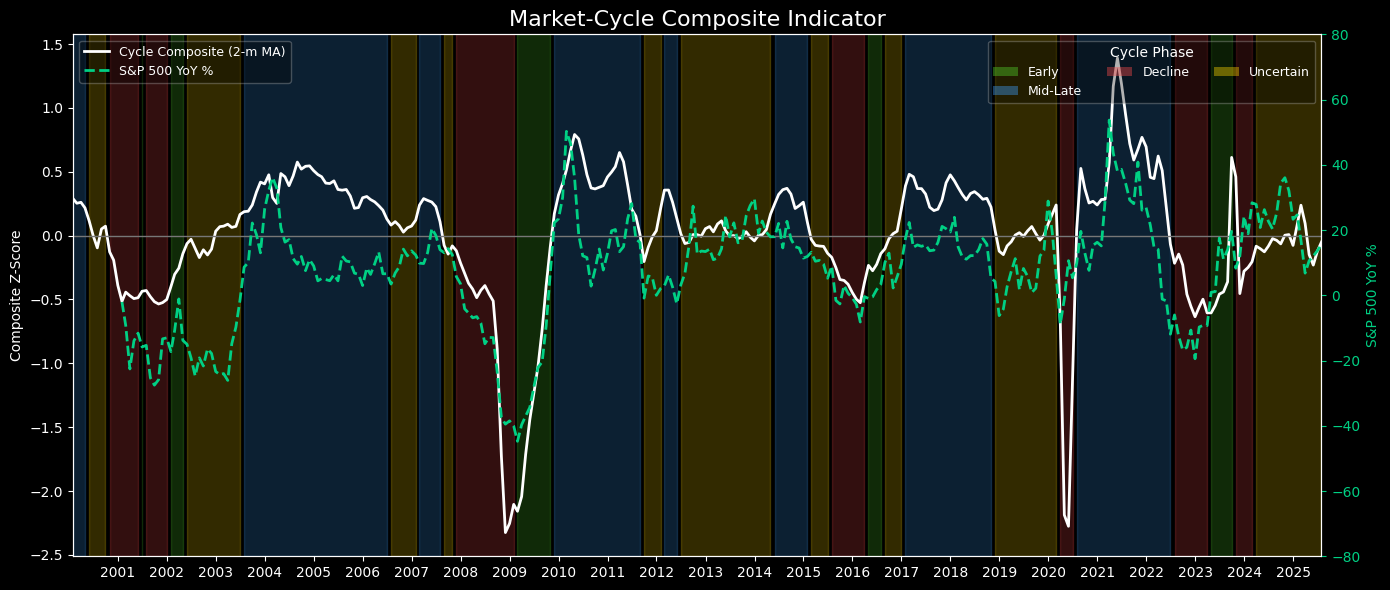

In [ ]:
# PLOT
fig, ax = plt.subplots(figsize=(14,6))

mask = pd.Series(phase, index=comp.index)
grp  = (mask != mask.shift()).cumsum()
for ph, col in phase_colors.items():
    for _, span in mask[mask==ph].groupby(grp):
        ax.axvspan(span.index[0], span.index[-1],
                   color=col, alpha=0.20)

ax.plot(comp_sm.index, comp_sm,
        lw=2, color='white',
        label=f'Cycle Composite ({SMOOTH_WINDOW}-m MA)')
ax.axhline(0, color='#777', lw=1)

ax2 = ax.twinx()
ax2.plot(spx_yoy.index, spx_yoy,
         lw=2, ls='--', color='#00d084',
         zorder=5,
         label='S&P 500 YoY %')
ax2.set_ylabel('S&P 500 YoY %', color='#00d084')
ax2.tick_params(axis='y', colors='#00d084')
ax2.set_ylim(-80, 80)

phase_patches = [Patch(facecolor=c, alpha=0.4, label=p)
                 for p, c in phase_colors.items()]
leg1 = ax.legend(handles=phase_patches, title='Cycle Phase',
                 loc='upper right', ncol=3,
                 framealpha=0.3, fontsize=9)

h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1+h2, l1+l2,
          loc='upper left', framealpha=0.3,
          fontsize=9)
ax.add_artist(leg1)

ax.set_title('Market-Cycle Composite Indicator', fontsize=16)
ax.set_ylabel('Composite Z-Score')
ax.set_xlim(comp.index[0], comp.index[-1])


# major tick: every year
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()


In [ ]:
# Dynamic Interpretation of Current Phase

# Reconstruct phase series with dates
phase_series    = pd.Series(phase, index=comp.index)
current_date    = phase_series.index[-1]
current_phase   = phase_series.iloc[-1]
current_comp    = comp_sm.loc[current_date]
current_slope   = slope.loc[current_date]
current_spx_yoy = spx_yoy.loc[current_date]

# Interpret by regime
if current_phase == 'Early':
    print(
        f"As of {current_date.date()}, the composite is {current_comp:.2f} "
        f"(+{current_slope:.3f} over {SLOPE_WINDOW}m) and S&P YoY is {current_spx_yoy:.1f}%. "
        "Early-phase conditions indicate nascent expansion. "
        "Leading activity indicators have bottomed and credit spreads are narrowing. "
        "Selective exposure to cyclical sectors may capture emerging growth while risks remain contained."
    )

elif current_phase == 'Mid-Late':
    print(
        f"As of {current_date.date()}, the composite stands at {current_comp:.2f} "
        f"(slope {current_slope:.3f}) with S&P YoY {current_spx_yoy:.1f}%. "
        "Mid-to-late cycle signals peak growth. "
        "Inflationary pressures and monetary tightening typically intensify in this phase. "
        "Shift allocation toward high-quality equities and defensive sectors to protect gains."
    )

elif current_phase == 'Decline':
    print(
        f"As of {current_date.date()}, the composite reads {current_comp:.2f} "
        f"(slope {current_slope:.3f}) and S&P YoY is {current_spx_yoy:.1f}%. "
        "Decline-phase patterns signal contraction. "
        "Risk sentiment deteriorates and liquidity tightens. "
        "Consider de-risking portfolios: increase fixed income, cash buffers, and low-volatility assets."
    )

elif current_phase == 'Uncertain':
    print(
        f"As of {current_date.date()}, the composite is neutral at {current_comp:.2f} "
        f"(slope {current_slope:.3f}) with S&P YoY {current_spx_yoy:.1f}%. "
        "Signals conflict and volatility often rises. "
        "Maintain balanced allocations, await clearer directional cues, and manage risk with disciplined stops."
    )

else:
    print("Phase classification unavailable.")


As of 2025-07-31, the composite is neutral at -0.05 (slope 0.308) with S&P YoY 15.7%. Signals conflict and volatility often rises. Maintain balanced allocations, await clearer directional cues, and manage risk with disciplined stops.
